In [1]:
from utils.common import prepare_dataset, data_split, train_catboost, calculate_metrics, get_most_important_features

df = prepare_dataset('../trading_small_df.csv',
                    exclude_cols=['cred_limit', 'fin_cond_index', 'tax_regime', 'reg_date', 'Unnamed: 0'], 
                    year_col='year',
                    id_col='vat_num',
                    dflt_col='dflt_year',
                    drop_fin_zeroes=True,
                    drop_ones_after_ones=True)


Длина датасета: 153841
Распределение таргета:
dflt_year
0    151926
1      1915
Name: count, dtype: int64


In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = data_split(df, train_year_max=2022, val_year=2023, test_year=2024, target_col="target")

model = train_catboost(X_train, 
                       y_train, 
                       X_val, 
                       y_val,
                       iterations_num=10_000,
                       eval_metric="AUC",
                       learning_rate=0.01,
                       random_seed=42,
                       verbose=200,
                       early_stopping_rounds=200,
                       class_weights=None)

0:	test: 0.8118078	best: 0.8118078 (0)	total: 68.3ms	remaining: 11m 22s
200:	test: 0.8834320	best: 0.8834801 (199)	total: 2.15s	remaining: 1m 44s
400:	test: 0.8921182	best: 0.8921273 (396)	total: 4.27s	remaining: 1m 42s
600:	test: 0.8947227	best: 0.8947275 (599)	total: 6.36s	remaining: 1m 39s
800:	test: 0.8962796	best: 0.8962796 (800)	total: 8.4s	remaining: 1m 36s
1000:	test: 0.8974340	best: 0.8974762 (980)	total: 10.5s	remaining: 1m 34s
1200:	test: 0.8976219	best: 0.8976309 (1192)	total: 12.6s	remaining: 1m 32s
1400:	test: 0.8981935	best: 0.8982127 (1393)	total: 14.5s	remaining: 1m 29s
1600:	test: 0.8982063	best: 0.8982944 (1543)	total: 16.6s	remaining: 1m 26s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8982943562
bestIteration = 1543

Shrink model to first 1544 iterations.


AUC: 0.9166449607297187
Brier: 0.11457969445039162
LogLoss: 0.46910044989763966

Top 20 features by importance:
                         feature  importance
0      debt_to_total_liabilities   12.770179
1                     roa_ru_tax    9.705016
2             absolute_liquidity    7.329742
3          total_assets_turnover    6.112857
4    receivables_to_total_assets    5.770582
5               days_purch_outst    4.631797
6               days_sales_outst    3.921901
7                     total_debt    3.006908
8              payables_turnover    2.966014
9                            roe    2.736757
10                  2110_revenue    2.658842
11            inventory_turnover    2.610988
12          receivables_turnover    2.584498
13       asset_conversion_period    2.404914
14               cogs_to_revenue    2.293027
15                           roa    2.271887
16             net_profit_margin    2.186615
17                          ebit    1.464017
18            net_debt_to equity 

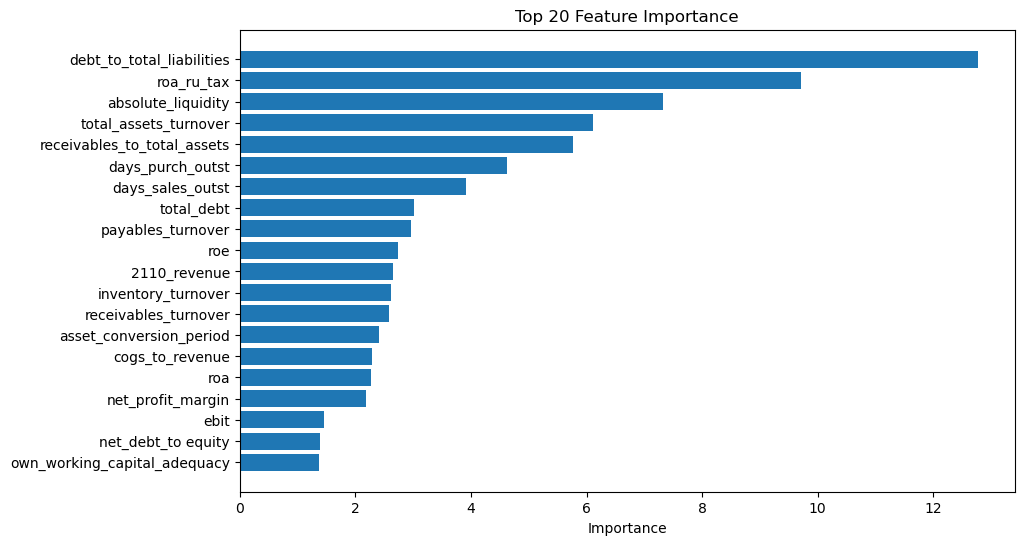

In [3]:
metrics = calculate_metrics(model, X_test, y_test)
fi_df = get_most_important_features(model, show=20)

In [4]:
from utils.common import calibrate_model

calibrated_model = calibrate_model(model, X_val, y_val)

In [5]:
calibrated_metrics = calculate_metrics(calibrated_model, X_test, y_test)

AUC: 0.9123933415167211
Brier: 0.09415081661822898
LogLoss: 0.31465392915653


In [6]:
from utils.exp_handler import save_exp

save_exp(X_train, 
         y_train, 
         X_val, 
         y_val, 
         X_test, 
         y_test,
         model,
         metrics=calibrated_metrics,
         fi_df=fi_df,
         calibrated_model=calibrated_model,
         name='small_df_no_lags',
         save_data=False)

'exp/small_df_no_lags'